# Import Libraries

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# load Dataset

In [47]:
df = pd.read_csv('UK Train Rides new.csv')

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31653 entries, 0 to 31652
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Transaction ID       31653 non-null  object
 1   Date of Purchase     31653 non-null  object
 2   Time of Purchase     31653 non-null  object
 3   Purchase Type        31653 non-null  object
 4   Payment Method       31653 non-null  object
 5   Railcard             10735 non-null  object
 6   Ticket Class         31653 non-null  object
 7   Ticket Type          31653 non-null  object
 8   Price                31653 non-null  int64 
 9   Departure Station    31653 non-null  object
 10  Arrival Destination  31653 non-null  object
 11  Date of Journey      31653 non-null  object
 12  Departure Time       31653 non-null  object
 13  Arrival Time         31653 non-null  object
 14  Actual Arrival Time  31653 non-null  object
 15  Journey Status       31653 non-null  object
 16  Refu

In [49]:
df.head()

,Transaction ID,Date of Purchase,Time of Purchase,Purchase Type,Payment Method,Railcard,Ticket Class,Ticket Type,Price,Departure Station,Arrival Destination,Date of Journey,Departure Time,Arrival Time,Actual Arrival Time,Journey Status,Refund Request
0,da8a6ba8-b3dc-4677-b176,2023-12-08,12:41:11,Online,Contactless,Adult,Standard,Advance,43,London Paddington,Liverpool Lime Street,2024-01-01,11:00:00,13:30:00,13:30:00,On Time,No
1,b0cdd1b0-f214-4197-be53,2023-12-16,11:23:01,Station,Credit Card,Adult,Standard,Advance,23,London Kings Cross,York,2024-01-01,09:45:00,11:35:00,11:40:00,Delayed,No
2,f3ba7a96-f713-40d9-9629,2023-12-19,19:51:27,Online,Credit Card,NaN,Standard,Advance,3,Liverpool Lime Street,Manchester Piccadilly,2024-01-02,18:15:00,18:45:00,18:45:00,On Time,No
3,b2471f11-4fe7-4c87-8ab4,2023-12-20,23:00:36,Station,Credit Card,NaN,Standard,Advance,13,London Paddington,Reading,2024-01-01,21:30:00,22:30:00,22:30:00,On Time,No
4,2be00b45-0762-485e-a7a3,2023-12-27,18:22:56,Online,Contactless,NaN,Standard,Advance,76,Liverpool Lime Street,London Euston,2024-01-01,16:45:00,19:00:00,19:00:00,On Time,No


# Data Cleaning

In [50]:
df.isnull().sum()

,0
Transaction ID,0
Date of Purchase,0
Time of Purchase,0
Purchase Type,0
Payment Method,0
Railcard,20918
Ticket Class,0
Ticket Type,0
Price,0
Departure Station,0


In [51]:
df['Price'].astype(str)

,Price
0,43
1,23
2,3
3,13
4,76
...,...
31648,4
31649,10
31650,4
31651,10


In [52]:
df['Railcard'].fillna('None')

,Railcard
0,Adult
1,Adult
2,None
3,None
4,None
...,...
31648,None
31649,None
31650,None
31651,None


# Feature Engineering

In [53]:
df['Date of Purchase'] = pd.to_datetime(df['Date of Purchase'])

In [54]:
df['Date of Journey'] = pd.to_datetime(df['Date of Journey'])

In [55]:
departure_td = pd.to_timedelta(df['Departure Time'])
arrival_td = pd.to_timedelta(df['Arrival Time'])
actual_arrival_td = pd.to_timedelta(df['Actual Arrival Time'])

# add columns
``



In [56]:
df['Duration'] = arrival_td - departure_td

In [57]:
df['Delay Time'] = actual_arrival_td - arrival_td

In [58]:
df['Booking Lead Time (Days)'] = (df['Date of Journey'] - df['Date of Purchase']).dt.days

In [59]:
df[['Departure Time', 'Arrival Time', 'Duration', 'Delay Time', 'Booking Lead Time (Days)']].head()

,Departure Time,Arrival Time,Duration,Delay Time,Booking Lead Time (Days)
0,11:00:00,13:30:00,0 days 02:30:00,0 days 00:00:00,24
1,09:45:00,11:35:00,0 days 01:50:00,0 days 00:05:00,16
2,18:15:00,18:45:00,0 days 00:30:00,0 days 00:00:00,14
3,21:30:00,22:30:00,0 days 01:00:00,0 days 00:00:00,12
4,16:45:00,19:00:00,0 days 02:15:00,0 days 00:00:00,5


In [60]:
df.head()

,Transaction ID,Date of Purchase,Time of Purchase,Purchase Type,Payment Method,Railcard,Ticket Class,Ticket Type,Price,Departure Station,Arrival Destination,Date of Journey,Departure Time,Arrival Time,Actual Arrival Time,Journey Status,Refund Request,Duration,Delay Time,Booking Lead Time (Days)
0,da8a6ba8-b3dc-4677-b176,2023-12-08,12:41:11,Online,Contactless,Adult,Standard,Advance,43,London Paddington,Liverpool Lime Street,2024-01-01,11:00:00,13:30:00,13:30:00,On Time,No,0 days 02:30:00,0 days 00:00:00,24
1,b0cdd1b0-f214-4197-be53,2023-12-16,11:23:01,Station,Credit Card,Adult,Standard,Advance,23,London Kings Cross,York,2024-01-01,09:45:00,11:35:00,11:40:00,Delayed,No,0 days 01:50:00,0 days 00:05:00,16
2,f3ba7a96-f713-40d9-9629,2023-12-19,19:51:27,Online,Credit Card,NaN,Standard,Advance,3,Liverpool Lime Street,Manchester Piccadilly,2024-01-02,18:15:00,18:45:00,18:45:00,On Time,No,0 days 00:30:00,0 days 00:00:00,14
3,b2471f11-4fe7-4c87-8ab4,2023-12-20,23:00:36,Station,Credit Card,NaN,Standard,Advance,13,London Paddington,Reading,2024-01-01,21:30:00,22:30:00,22:30:00,On Time,No,0 days 01:00:00,0 days 00:00:00,12
4,2be00b45-0762-485e-a7a3,2023-12-27,18:22:56,Online,Contactless,NaN,Standard,Advance,76,Liverpool Lime Street,London Euston,2024-01-01,16:45:00,19:00:00,19:00:00,On Time,No,0 days 02:15:00,0 days 00:00:00,5


# Saveing the data clean

In [61]:
df.to_csv('UK_Train_Rides_Cleaned.csv', index=False)

# Data preparation + KPI calculation

In [62]:
df = pd.read_csv('UK Train Rides new.csv')
df['Railcard'] = df['Railcard'].fillna('None')

In [63]:
df['Date of Purchase'] = pd.to_datetime(df['Date of Purchase'])
df['Date of Journey'] = pd.to_datetime(df['Date of Journey'])

In [64]:
departure_td = pd.to_timedelta(df['Departure Time'])
arrival_td = pd.to_timedelta(df['Arrival Time'])
actual_arrival_td = pd.to_timedelta(df['Actual Arrival Time'])

# add columns

In [65]:
df['Duration'] = arrival_td - departure_td
df['Delay Time'] = actual_arrival_td - arrival_td
df['Booking Lead Time (Days)'] = (df['Date of Journey'] - df['Date of Purchase']).dt.days

# KPI

In [66]:
avg_price = df['Price'].mean()
total_revenue = df['Price'].sum()

In [67]:
valid_trips = df[df['Journey Status'] != 'Cancelled'].copy()
delay_mins = (pd.to_timedelta(valid_trips['Actual Arrival Time']) - pd.to_timedelta(valid_trips['Arrival Time'])).dt.total_seconds() / 60.0
avg_delay = delay_mins.mean()

In [68]:
print("KPIs Summary:")
print("Average Price:", round(avg_price, 2))
print("Total Revenue:", total_revenue)
print("Average Delay (mins):", round(avg_delay, 2))

KPIs Summary:
Average Price: 23.44
Total Revenue: 741921
Average Delay (mins): 3.25


# Charts

# Line Chart:للرحلات اليوميه

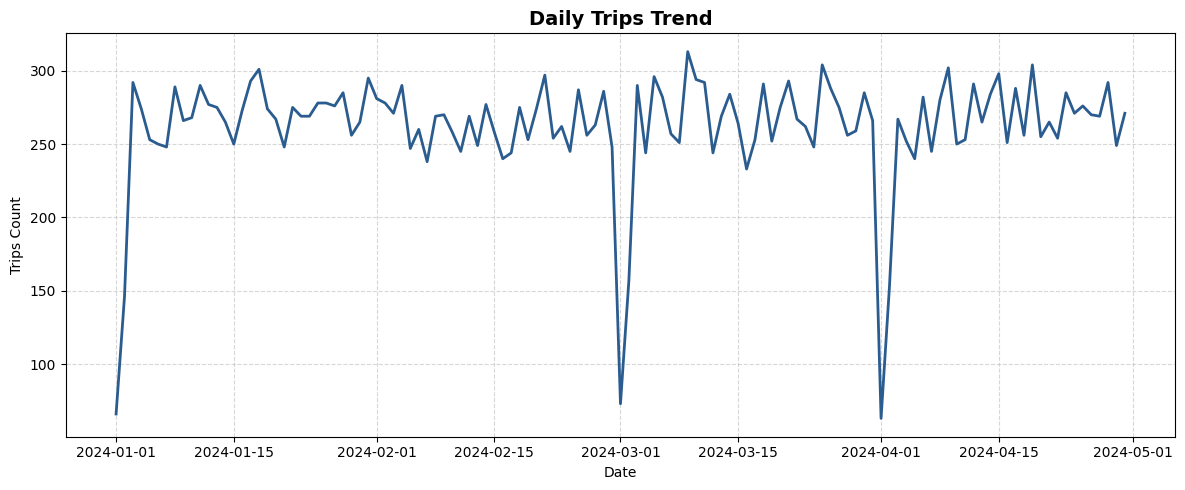

In [69]:
daily_trips = df.groupby('Date of Journey').size().reset_index(name='Total Trips')

plt.figure(figsize=(12, 5))
plt.plot(daily_trips['Date of Journey'], daily_trips['Total Trips'], color='#2b5c8f', linewidth=2)

plt.title('Daily Trips Trend', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Trips Count')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Pie Chart الخاص بـ Railcards كروت التخفيض

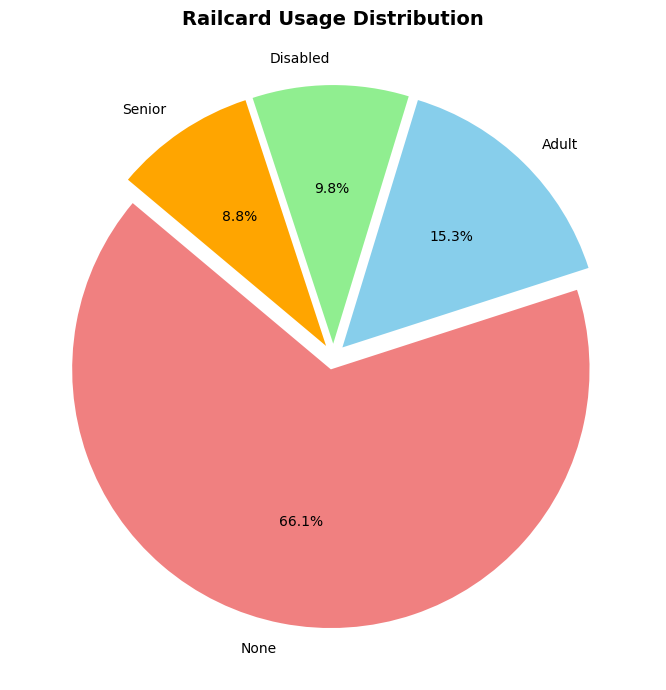

In [70]:
railcard_counts = df['Railcard'].value_counts()


plt.figure(figsize=(7, 7))


colors = ['lightcoral', 'skyblue', 'lightgreen', 'orange']

plt.pie(railcard_counts,
        labels=railcard_counts.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=colors,
        explode=[0.05]*len(railcard_counts))

plt.title('Railcard Usage Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Booking Lead Time:

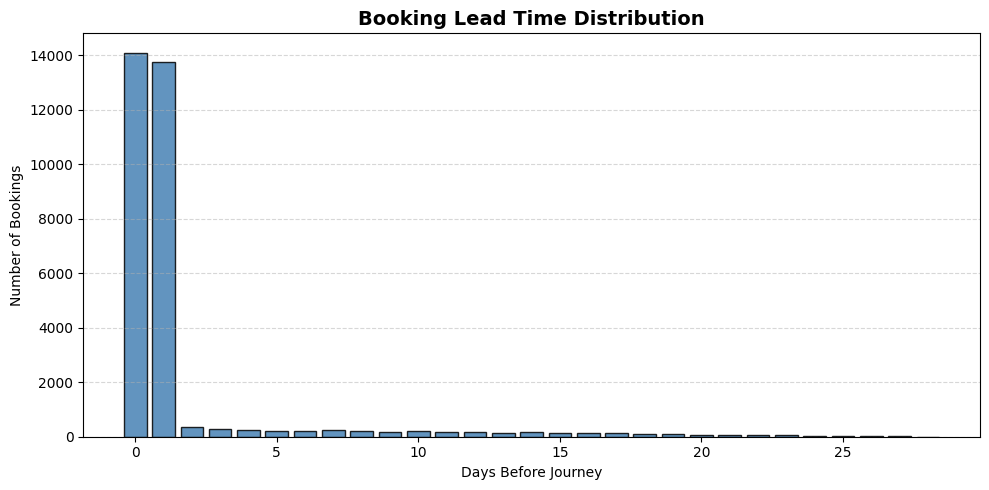

In [71]:
booking_counts = df['Booking Lead Time (Days)'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.bar(booking_counts.index, booking_counts.values, color='steelblue', edgecolor='black', alpha=0.85)

plt.title('Booking Lead Time Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Days Before Journey')
plt.ylabel('Number of Bookings')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Horizontal Bar Chart:

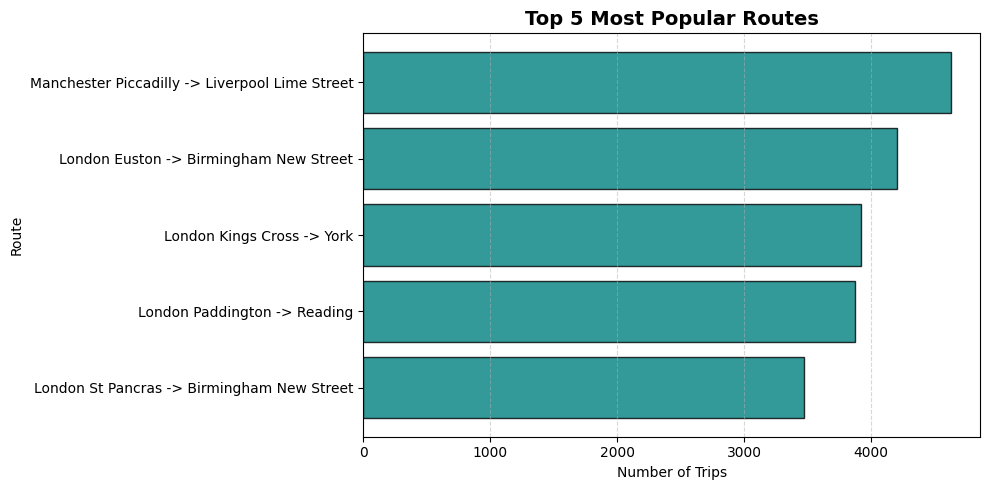

In [72]:
df['Route'] = df['Departure Station'] + ' -> ' + df['Arrival Destination']
top_routes = df['Route'].value_counts().head(5)

plt.figure(figsize=(10, 5))
plt.barh(top_routes.index[::-1], top_routes.values[::-1], color='teal', edgecolor='black', alpha=0.8)


plt.title('Top 5 Most Popular Routes', fontsize=14, fontweight='bold')
plt.xlabel('Number of Trips')
plt.ylabel('Route')
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Pie Chart:Journey Status

In [73]:

import plotly.express as px

status_counts = df['Journey Status'].value_counts().reset_index()
status_counts.columns = ['Journey Status', 'Count']

color_map = {
    'On Time': 'green',
    'Delayed': 'orange',
    'Cancelled': 'red'
}

fig = px.pie(
    status_counts,
    values='Count',
    names='Journey Status',
    title='<b>Journey Status Distribution</b>',
    color='Journey Status',
    color_discrete_map=color_map,
    hole=0.3
)

fig.update_traces(
    textposition='inside',
    textinfo='percent+label',
    marker=dict(line=dict(color='white', width=2))
)

fig.update_layout(
    font=dict(family="Arial, sans-serif", size=13),
    title_font_size=18,
    showlegend=True
)

fig.show()

# Delay & Cancellation by Route

In [74]:
route_perf = df.groupby('Route')['Journey Status'].value_counts(normalize=True).unstack().fillna(0) * 100

In [75]:
route_perf.sort_values(by='Cancelled', ascending=False).head(5)

Journey Status,Cancelled,Delayed,On Time
Route,,,
Liverpool Lime Street -> Birmingham New Street,14.285714,0.0,85.714286
London Paddington -> Oxford,12.989691,0.0,87.010309
York -> Birmingham New Street,12.500000,0.0,87.500000
Reading -> Didcot,12.500000,0.0,87.500000
Birmingham New Street -> London Paddington,12.500000,0.0,87.500000


# Trips & Revenue by Time of Day

In [76]:
df['Departure Hour'] = pd.to_timedelta(df['Departure Time'].astype(str)).dt.components['hours']

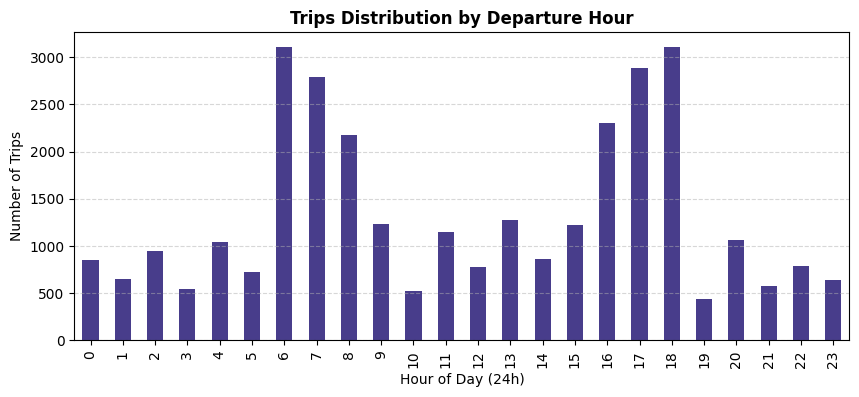

In [77]:
plt.figure(figsize=(10, 4))
df['Departure Hour'].value_counts().sort_index().plot(kind='bar', color='darkslateblue')
plt.title('Trips Distribution by Departure Hour', fontsize=12, fontweight='bold')
plt.xlabel('Hour of Day (24h)')
plt.ylabel('Number of Trips')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# Delay vs. Ticket Type or Railcard

In [78]:
valid_trips = df[df['Journey Status'] != 'Cancelled'].copy()
valid_trips['Delay_Mins'] = (pd.to_timedelta(valid_trips['Actual Arrival Time']) - pd.to_timedelta(valid_trips['Arrival Time'])).dt.total_seconds() / 60.0

delay_by_railcard = valid_trips.groupby('Railcard')['Delay_Mins'].mean()
print(delay_by_railcard)

Railcard
Adult       6.310919
Disabled    2.113487
None        3.055787
Senior      0.539378
Name: Delay_Mins, dtype: float64


# Average Ticket Price per Route

In [79]:
route_price = df.groupby('Route')['Price'].mean().sort_values(ascending=False).head(5)
print(route_price)

Route
Manchester Piccadilly -> London Paddington    114.111111
Liverpool Lime Street -> London St Pancras    104.774194
Liverpool Lime Street -> London Euston        103.280766
Liverpool Lime Street -> London Paddington     99.962963
Manchester Piccadilly -> London St Pancras     99.562500
Name: Price, dtype: float64
